# Modular Experimental System: Learning Curve Extrapolation

## Section 0: Configuration Dictionary (`CFG`)

In [1]:

import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.optimize import curve_fit, OptimizeWarning
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import norm
from joblib import Parallel, delayed
from pprint import pprint
import datetime

warnings.filterwarnings('ignore')

CFG = {
    'experiment_name': 'sub11_ridge_pow2_learners',
    'data': {
        'train_path': 'data/LCDB11_ER_train.hdf5',
        'eval_path': 'data/LCDB11_ER_eval.hdf5',
        'val_split': 0.1,  
        'random_seed': 42
    },
    'features': {
        'use_params': True,
        'use_stats': True,
        'use_ohe_learners': True, # options: True or False
    },
    'preprocessing': {
        'nan_handling': 'forward'
    },
    'fitting': {
        'method': 'pow2', # 'pow2', 'pow3', 'exp3', 'mmf4', 'wbl4'
        'n_inits': 5,
        'n_jobs': 4
    },
    'model': {
        # options: 'ridge', 'rf', 'hgb' (HistGradientBoosting)
        'type': 'ridge', 
    },
    'tuning': {
        # 'none', 'grid' (GridSearchCV), 'halving' (HalvingGridSearchCV)
        'method': 'grid', 
        'cv_folds': 3,
        'n_jobs': 4
    },
    'uncertainty': {
        'method': 'gaussian', # 'gaussian', 'kde', 'conformal', 'quantile'
    },
    'submission': {
        'demo_path': 'data/demo_submission.csv',
        'out_dir': 'submissions'
    }
}

np.random.seed(CFG['data']['random_seed'])
pprint(CFG)


{'data': {'eval_path': 'data/LCDB11_ER_eval.hdf5',
          'random_seed': 42,
          'train_path': 'data/LCDB11_ER_train.hdf5',
          'val_split': 0.1},
 'experiment_name': 'sub11_ridge_pow2_learners',
 'features': {'use_ohe_learners': True, 'use_params': True, 'use_stats': True},
 'fitting': {'method': 'pow2', 'n_inits': 5, 'n_jobs': 4},
 'model': {'type': 'ridge'},
 'preprocessing': {'nan_handling': 'forward'},
 'submission': {'demo_path': 'data/demo_submission.csv',
                'out_dir': 'submissions'},
 'tuning': {'cv_folds': 3, 'method': 'grid', 'n_jobs': 4},
 'uncertainty': {'method': 'gaussian'}}


## Section 1: Data Ingestion & Inspection

In [2]:
max_k = 136 
anchor_list = [int(np.ceil(16 * (2 ** (k / 8)))) for k in range(max_k + 1)]
x_anchors_all = np.array(anchor_list)

def load_hdf5_data(path):
    out = {}
    with h5py.File(path, 'r') as f:
        for key in f.keys():
            data = f[key][()]
            if data.dtype.kind == 'S':  
                data = [s.decode('utf-8') for s in data]
            out[key] = np.array(data)
    return out

train_data = load_hdf5_data(CFG['data']['train_path'])
eval_data = load_hdf5_data(CFG['data']['eval_path'])
train_full = train_data['error rate']
eval_full = eval_data['error rate']

def extract_train_curves(y_full, learner_full=None):
    y_obs_list, y_tgt_list, m_list, valid_idx = [], [], [], []
    learner_list = []

    for i in range(y_full.shape[0]):
        curve = y_full[i]
        non_nans = np.where(~np.isnan(curve))[0]
        if len(non_nans) == 0:
            continue

        L = non_nans[-1] + 1

        if L > 16:
            M = L - 16
            y_obs_list.append(curve[:M])
            y_tgt_list.append(curve[L - 1])
            m_list.append(M)
            valid_idx.append(i)

            if learner_full is not None:
                learner_list.append(learner_full[i])

    if learner_full is not None:
        return y_obs_list, np.array(y_tgt_list), m_list, valid_idx, np.array(learner_list)

    return y_obs_list, np.array(y_tgt_list), m_list, valid_idx

def extract_eval_curves(y_full, learner_full=None):
    y_obs_list, m_list = [], []
    learner_list = []

    for i in range(y_full.shape[0]):
        curve = y_full[i]
        non_nans = np.where(~np.isnan(curve))[0]

        if len(non_nans) == 0:
            M = 0
            y_obs_list.append(np.array([]))
        else:
            M = non_nans[-1] + 1
            y_obs_list.append(curve[:M])

        m_list.append(M)

        if learner_full is not None:
            learner_list.append(learner_full[i])

    if learner_full is not None:
        return y_obs_list, m_list, np.array(learner_list)

    return y_obs_list, m_list

train_learner_full = np.asarray(train_data["learner"]).reshape(-1)
y_train_obs, y_train_tgt, train_m, train_valid_idx, train_learner = extract_train_curves(train_full, train_learner_full)

eval_learner_full = np.asarray(eval_data["learner"]).reshape(-1)
y_eval_obs, eval_m, eval_learner = extract_eval_curves(eval_full, eval_learner_full)

## Section 2: Preprocessing & NaN Handling

In [3]:
def clean_curve(curve):
    if len(curve) == 0: return curve
    if np.isnan(curve).any():
        df = pd.Series(curve).ffill().bfill()
        return df.to_numpy()
    return curve

y_train_clean = [clean_curve(c) for c in y_train_obs]
y_eval_clean = [clean_curve(c) for c in y_eval_obs]

## Section 3: Parametric Curve Fitting

In [4]:
def pow2(x, a, c): return a * (x**(-c))
def pow3(x, a, c, c0): return a * (x**(-c)) + c0
def exp3(x, a, c, c0): return a * np.exp(-c * x) + c0
def mmf4(x, a, b, c, d): return (a * b + c * (x**d)) / (b + (x**d))

def fit_curve(y_curve, x_anchors, method, n_inits=1):
    if len(y_curve) < 3: 
        if method in ['pow2']: return [0.0]*2
        if method in ['pow3', 'exp3']: return [0.0]*3
        if method in ['mmf4']: return [0.0]*4
        
    func = {'pow2': pow2, 'pow3': pow3, 'exp3': exp3, 'mmf4': mmf4}[method]
    n_params = func.__code__.co_argcount - 1
    
    best_params = [0.0] * n_params
    best_mse = float('inf')
    
    for _ in range(n_inits):
        try:
            p0 = [np.random.uniform(0.01, 1.0) for _ in range(n_params)]
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", OptimizeWarning)
                warnings.simplefilter("ignore", RuntimeWarning)
                params, _ = curve_fit(func, x_anchors, y_curve, p0=p0, maxfev=400)
            y_pred = func(x_anchors, *params)
            mse = mean_squared_error(y_curve, y_pred)
            if mse < best_mse:
                best_mse = mse
                best_params = params
        except Exception: continue
        
    return np.array(best_params)

def extract_fit_features(y_cleaned_list, m_list):
    if not CFG['features']['use_params']:
        return None
    method = CFG['fitting']['method']
    n_inits = CFG['fitting']['n_inits']
    n_jobs = CFG['fitting']['n_jobs']
    
    params_list = Parallel(n_jobs=n_jobs)(
        delayed(fit_curve)(y_cleaned_list[i], x_anchors_all[:m_list[i]], method, n_inits)
        for i in range(len(y_cleaned_list))
    )
    return np.array(params_list)

def extract_stats_features(y_cleaned_list):
    if not CFG['features']['use_stats']:
        return None
    stats = []
    for curve in y_cleaned_list:
        if len(curve) > 0:
            stats.append([np.mean(curve), np.std(curve), np.min(curve), np.max(curve), curve[-1]])
        else:
            stats.append([0.0]*5)
    return np.array(stats)

train_fit_params = extract_fit_features(y_train_clean, train_m)
eval_fit_params = extract_fit_features(y_eval_clean, eval_m)

train_stats = extract_stats_features(y_train_clean)
eval_stats = extract_stats_features(y_eval_clean)

## Section 4: Feature Engineering

In [5]:
def build_features(m_list, fit_params, stats_features, learner_array=None, learner_categs=None):
    features = []

    m_array = np.array(m_list).reshape(-1, 1)
    features.append(m_array)

    if CFG['features']['use_params']:
        features.append(fit_params)

    if CFG['features']['use_stats']:
        features.append(stats_features)

    if CFG['features']['use_ohe_learners']:

        learner_array = np.array(learner_array)

        if learner_categs is None:
            learner_categs = np.unique(learner_array)

        learner_to_index = { learner_value: learner_index for learner_index, learner_value in enumerate(learner_categs)}
        learner_one_hot = np.zeros((len(learner_array), len(learner_categs)), dtype=float)

        for row_index, learner_value in enumerate(learner_array):
            if learner_value in learner_to_index:
                learner_one_hot[row_index, learner_to_index[learner_value]] = 1.0

        features.append(learner_one_hot)

    return np.hstack(features)

use_learners = CFG['features']['use_ohe_learners']
learner_categories = np.unique(train_learner) if use_learners else None

X_train = build_features(
    train_m,
    train_fit_params,
    train_stats,
    learner_array=train_learner if use_learners else None,
    learner_categs=learner_categories
)

X_eval = build_features(
    eval_m,
    eval_fit_params,
    eval_stats,
    learner_array=eval_learner if use_learners else None,
    learner_categs=learner_categories
)
y_train_tgt = np.array(y_train_tgt)

## Section 5: Meta-Model Training & Optimization

In [6]:
X_t, X_v, y_t, y_v = train_test_split(
    X_train, y_train_tgt, 
    test_size=CFG['data']['val_split'], 
    random_state=CFG['data']['random_seed']
)

model_type = CFG['model']['type']
tuning_method = CFG['tuning']['method']

# Limited Hyperparameter Grids to prevent massive unconstrained values
if model_type == 'ridge':
    base_model = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
    param_grid = {'model__alpha': [0.1, 1.0, 10.0, 50.0]} 
elif model_type == 'rf':
    base_model = Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(random_state=42))])
    param_grid = {'model__n_estimators': [50, 100], 'model__max_depth': [5, 10]} 
elif model_type == 'hgb':
    base_model = Pipeline([('scaler', StandardScaler()), ('model', HistGradientBoostingRegressor(random_state=42))])
    param_grid = {'model__learning_rate': [0.05, 0.1], 'model__max_iter': [100], 'model__max_depth': [3, 5]} 
else:
    raise ValueError("Unknown model_type")

if tuning_method == 'grid':
    model = GridSearchCV(base_model, param_grid, cv=CFG['tuning']['cv_folds'], 
                         scoring='neg_mean_squared_error', n_jobs=CFG['tuning']['n_jobs'])
    model.fit(X_t, y_t)
elif tuning_method == 'halving':
    model = HalvingGridSearchCV(base_model, param_grid, cv=CFG['tuning']['cv_folds'], 
                                scoring='neg_mean_squared_error', n_jobs=CFG['tuning']['n_jobs'],
                                random_state=42, factor=3)
    model.fit(X_t, y_t)
else:
    model = base_model
    model.fit(X_t, y_t)
    
y_pred_t = model.predict(X_t)
y_pred_v = model.predict(X_v)
y_pred_eval = model.predict(X_eval)

## Section 6: Uncertainty Estimation

In [7]:
residuals = y_v - y_pred_v
sigma = np.std(residuals)

def construct_probability_bins(preds, sigma, n_bins=1000):
    bins = np.linspace(0, 1, n_bins)
    probs = []
    for p in preds:
        dist = norm.pdf(bins, loc=p, scale=sigma)
        dist = np.clip(dist, a_min=1e-10, a_max=None)
        dist = dist / np.sum(dist)
        probs.append(dist)
    return np.array(probs, dtype=np.float32)

val_probs = construct_probability_bins(y_pred_v, sigma)
eval_probs = construct_probability_bins(y_pred_eval, sigma)


## Section 7: Local Evaluation

In [8]:
def calculate_median_nll(probs, true_y, n_bins=1000):
    bin_idx = np.clip(np.floor(true_y * n_bins).astype(int), 0, n_bins - 1)
    prob_true = probs[np.arange(len(probs)), bin_idx]
    nll = -np.log(prob_true)
    return np.median(nll)

median_nll = calculate_median_nll(val_probs, y_v)


## Section 8: Kaggle Submission & Diagnostics

Experiment logged to experiment_logs.csv.


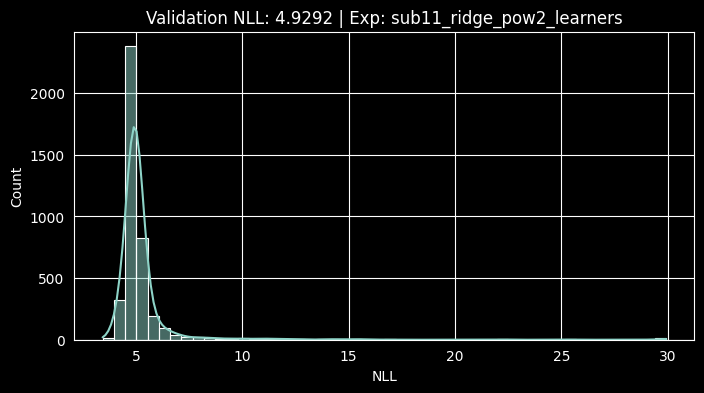

In [9]:

n_bins = eval_probs.shape[1]
df_sub = pd.DataFrame(eval_probs, columns=[f"bin_{i}" for i in range(n_bins)])
df_sub.insert(0, "id", np.arange(len(eval_probs)))

out_dir = CFG['submission']['out_dir']
os.makedirs(out_dir, exist_ok=True)
exp_name = CFG['experiment_name']
out_path = os.path.join(out_dir, f"sub_{exp_name}.csv")
df_sub.to_csv(out_path, index=False)

log_path = 'experiment_logs.csv'
log_data = {
    'timestamp': pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
    'experiment_name': exp_name,
    'model_type': CFG['model']['type'],
    'fitting_method': CFG['fitting']['method'],
    'features': str({'params': CFG['features']['use_params'], 'stats': CFG['features']['use_stats']}),
    'tuning_method': CFG['tuning']['method'],
    'best_params': str(getattr(model, 'best_params_', 'None')),
    'local_median_nll': median_nll
}

df_log = pd.DataFrame([log_data])
if os.path.exists(log_path):
    df_log.to_csv(log_path, mode='a', header=False, index=False)
else:
    df_log.to_csv(log_path, index=False)
    
print(f"Experiment logged to {log_path}.")

bin_idx = np.clip(np.floor(y_v * 1000).astype(int), 0, 999)
prob_true = val_probs[np.arange(len(val_probs)), bin_idx]
nlls = -np.log(prob_true)

plt.figure(figsize=(8,4))
sns.histplot(nlls, bins=50, kde=True)
plt.title(f"Validation NLL: {median_nll:.4f} | Exp: {exp_name}")
plt.xlabel("NLL")
plt.show()
